# Analisis Holt-Winters (ETS) untuk Prediksi Pengiriman Paket

In [1]:
# Import Libraries untuk Analisis Holt-Winters (ETS)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from prophet.make_holidays import make_holidays_df
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from itertools import product
import json
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

print("Libraries berhasil dimuat!")
print("Notebook ini akan membandingkan 3 model: SARIMA, Prophet, dan Holt-Winters (ETS)")
print("Grid Search akan dilakukan untuk menemukan parameter optimal")

Libraries berhasil dimuat!
Notebook ini akan membandingkan 3 model: SARIMA, Prophet, dan Holt-Winters (ETS)
Grid Search akan dilakukan untuk menemukan parameter optimal


## Load dan Preprocessing Data

In [2]:
# Load Data
df = pd.read_csv("../data/data_kiriman_converted.csv")

# Data Preprocessing
df = df[['Kota', 'Cek', 'Tgl_Kirim']]

# Konversi Tgl_Kirim ke datetime
df['Tgl_Kirim'] = pd.to_datetime(df['Tgl_Kirim'])

df['Kecamatan'] = df['Kota'].apply(lambda x: x.split(',')[1].strip() if len(x.split(',')) > 1 else '')
df = df[['Kecamatan', 'Cek', 'Tgl_Kirim']]

# Agregasi mingguan per kecamatan
df_kecamatan_weekly = df.groupby('Kecamatan').resample('W', on='Tgl_Kirim')['Cek'].count().reset_index()
df_kecamatan_weekly.rename(columns={'Cek': 'total paket'}, inplace=True)
df_kecamatan_weekly['minggu_ke'] = df_kecamatan_weekly['Tgl_Kirim'].dt.isocalendar().week.astype(int)

unique_kecamatan = df_kecamatan_weekly['Kecamatan'].unique()

print("="*70)
print("DATA BERHASIL DIMUAT!")
print("="*70)
print(f"- Total Kecamatan: {len(unique_kecamatan)}")
print(f"- Kecamatan: {', '.join(unique_kecamatan)}")
print(f"- Total data: {len(df_kecamatan_weekly)} minggu")
print(f"- Rentang data: {df_kecamatan_weekly['Tgl_Kirim'].min().date()} s/d {df_kecamatan_weekly['Tgl_Kirim'].max().date()}")
print("="*70)

display(df_kecamatan_weekly.head(10))

DATA BERHASIL DIMUAT!
- Total Kecamatan: 5
- Kecamatan: BLIMBING, KEDUNGKANDANG, KLOJEN, LOWOKWARU, SUKUN
- Total data: 1050 minggu
- Rentang data: 2020-12-27 s/d 2024-12-29


,Kecamatan,Tgl_Kirim,total paket,minggu_ke
0,BLIMBING,2020-12-27,7,52
1,BLIMBING,2021-01-03,217,53
2,BLIMBING,2021-01-10,518,1
3,BLIMBING,2021-01-17,432,2
4,BLIMBING,2021-01-24,446,3
5,BLIMBING,2021-01-31,423,4
6,BLIMBING,2021-02-07,550,5
7,BLIMBING,2021-02-14,323,6
8,BLIMBING,2021-02-21,546,7
9,BLIMBING,2021-02-28,531,8


## Grid Search Holt-Winters (ETS) - Optimasi Parameter

In [5]:
print("🔍 Memulai Grid Search HOLT-WINTERS (ETS) untuk Optimasi Hyperparameter")
print("="*80)

# Define parameter grid untuk Holt-Winters
trend_options = [None, 'add', 'mul']
seasonal_options = ['add', 'mul']
damped_options = [True, False]
seasonal_periods = 52  # Weekly data dengan seasonal tahunan

# Hitung total kombinasi
total_combinations = len(trend_options) * len(seasonal_options) * len(damped_options)

print(f"\nParameter Grid:")
print(f"   - Trend: {len(trend_options)} opsi {trend_options}")
print(f"   - Seasonal: {len(seasonal_options)} opsi {seasonal_options}")
print(f"   - Damped: {len(damped_options)} opsi {damped_options}")
print(f"   - Seasonal Periods: {seasonal_periods} (mingguan)")
print(f"\nTotal kombinasi yang akan diuji: {total_combinations} per kecamatan")
print(f"Estimasi waktu per kecamatan: ~{total_combinations * 3 / 60:.1f} menit")
print("="*80)

# Buat folder models jika belum ada
os.makedirs('../models', exist_ok=True)

# Dictionary untuk menyimpan hasil optimasi
holtwinters_results = {}

for kecamatan in unique_kecamatan:
    print(f"\n{'='*80}")
    print(f"Optimasi Holt-Winters untuk Kecamatan: {kecamatan}")
    print(f"{'='*80}")
    
    # Filter dan split data
    df_filtered = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan].copy()
    split_point = len(df_filtered) - 52
    
    train = df_filtered.iloc[:split_point].copy()
    test = df_filtered.iloc[split_point:].copy()
    
    # Set index untuk time series
    train_ts = train.set_index('Tgl_Kirim')['total paket']
    test_ts = test.set_index('Tgl_Kirim')['total paket']
    
    best_mape = float('inf')
    best_params = None
    best_model = None
    best_forecast = None
    
    tested = 0
    
    # Grid Search
    for trend in trend_options:
        for seasonal in seasonal_options:
            for damped in damped_options:
                tested += 1
                
                # Skip invalid combinations
                if trend is None and damped:
                    continue
                
                try:
                    # Fit Holt-Winters model
                    model = ExponentialSmoothing(
                        train_ts,
                        trend=trend,
                        seasonal=seasonal,
                        seasonal_periods=seasonal_periods,
                        damped_trend=damped
                    )
                    
                    fitted_model = model.fit(optimized=True)
                    
                    # Prediksi
                    forecast = fitted_model.forecast(steps=52)
                    
                    # Evaluasi
                    y_true = test_ts.values
                    y_pred = forecast.values
                    
                    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
                    
                    # Update best model
                    if mape < best_mape:
                        best_mape = mape
                        best_params = {
                            'trend': trend,
                            'seasonal': seasonal,
                            'damped_trend': damped
                        }
                        best_model = fitted_model
                        best_forecast = forecast
                        
                        print(f"✨ [{tested}/{total_combinations}] MAPE TERBAIK BARU: {mape:.4f}%")
                        print(f"   Params: trend={trend}, seasonal={seasonal}, damped={damped}")
                    
                except Exception as e:
                    print(f"Error - trend={trend}, seasonal={seasonal}, damped={damped}: {str(e)[:50]}")
                    continue
    
    # Hitung metrik untuk best model
    mae = mean_absolute_error(test_ts.values, best_forecast.values)
    rmse = np.sqrt(mean_squared_error(test_ts.values, best_forecast.values))
    
    # Status berdasarkan MAPE
    if best_mape < 10:
        status = "Sangat Baik"
    elif best_mape < 20:
        status = "Baik"
    elif best_mape < 50:
        status = "Cukup"
    else:
        status = "Buruk"
    
    # Simpan model Holt-Winters ke disk
    model_filename = f'../models/holtwinters_model_{kecamatan}.pkl'
    joblib.dump(best_model, model_filename)
    print(f"\nModel Holt-Winters disimpan: {model_filename}")
    
    # Simpan hasil
    holtwinters_results[kecamatan] = {
        'params': best_params,
        'model': best_model,
        'forecast': best_forecast,
        'train': train,
        'test': test,
        'metrics': {
            'MAPE': best_mape,
            'MAE': mae,
            'RMSE': rmse,
            'Status': status
        }
    }
    
    print(f"\n{'='*80}")
    print(f"HASIL OPTIMASI TERBAIK - {kecamatan}")
    print(f"{'='*80}")
    print(f"Best Parameters:")
    print(f"   - Trend: {best_params['trend']}")
    print(f"   - Seasonal: {best_params['seasonal']}")
    print(f"   - Damped Trend: {best_params['damped_trend']}")
    print(f"\nMetrics:")
    print(f"   - MAPE: {best_mape:.4f}% {status}")
    print(f"   - MAE: {mae:.2f}")
    print(f"   - RMSE: {rmse:.2f}")

# Summary hasil Holt-Winters
print(f"\n{'='*80}")
print("RINGKASAN HASIL HOLT-WINTERS - SEMUA KECAMATAN")
print(f"{'='*80}\n")

hw_summary = pd.DataFrame({
    kec: {
        'MAPE': res['metrics']['MAPE'],
        'MAE': res['metrics']['MAE'],
        'RMSE': res['metrics']['RMSE'],
        'Trend': res['params']['trend'],
        'Seasonal': res['params']['seasonal'],
        'Damped': res['params']['damped_trend'],
        'Status': res['metrics']['Status']
    } for kec, res in holtwinters_results.items()
}).T

display(hw_summary)

print(f"\nStatistik Holt-Winters:")
print(f"   - Rata-rata MAPE: {hw_summary['MAPE'].mean():.4f}%")
print(f"   - MAPE Terbaik: {hw_summary['MAPE'].min():.4f}% ({hw_summary['MAPE'].idxmin()})")
print(f"   - MAPE Terburuk: {hw_summary['MAPE'].max():.4f}% ({hw_summary['MAPE'].idxmax()})")
print(f"   - Standar Deviasi: {hw_summary['MAPE'].std():.4f}%")

print(f"\nSemua model Holt-Winters berhasil disimpan di folder: ../models/")


🔍 Memulai Grid Search HOLT-WINTERS (ETS) untuk Optimasi Hyperparameter

Parameter Grid:
   - Trend: 3 opsi [None, 'add', 'mul']
   - Seasonal: 2 opsi ['add', 'mul']
   - Damped: 2 opsi [True, False]
   - Seasonal Periods: 52 (mingguan)

Total kombinasi yang akan diuji: 12 per kecamatan
Estimasi waktu per kecamatan: ~0.6 menit

Optimasi Holt-Winters untuk Kecamatan: BLIMBING
✨ [2/12] MAPE TERBAIK BARU: 16.0303%
   Params: trend=None, seasonal=add, damped=False
✨ [4/12] MAPE TERBAIK BARU: 15.7453%
   Params: trend=None, seasonal=mul, damped=False
✨ [6/12] MAPE TERBAIK BARU: 11.3347%
   Params: trend=add, seasonal=add, damped=False
✨ [9/12] MAPE TERBAIK BARU: 11.3262%
   Params: trend=mul, seasonal=add, damped=True

Model Holt-Winters disimpan: ../models/holtwinters_model_BLIMBING.pkl

HASIL OPTIMASI TERBAIK - BLIMBING
Best Parameters:
   - Trend: mul
   - Seasonal: add
   - Damped Trend: True

Metrics:
   - MAPE: 11.3262% Baik
   - MAE: 99.33
   - RMSE: 139.41

Optimasi Holt-Winters untu

,MAPE,MAE,RMSE,Trend,Seasonal,Damped,Status
BLIMBING,11.326208,99.332437,139.41071,mul,add,True,Baik
KEDUNGKANDANG,10.254513,72.068404,88.944655,add,add,False,Baik
KLOJEN,9.000099,189.303302,243.984122,add,mul,False,Sangat Baik
LOWOKWARU,11.081303,125.525687,170.177368,mul,add,True,Baik
SUKUN,12.632116,127.050798,355.254362,add,add,False,Baik



Statistik Holt-Winters:
   - Rata-rata MAPE: 10.8588%
   - MAPE Terbaik: 9.0001% (KLOJEN)
   - MAPE Terburuk: 12.6321% (SUKUN)
   - Standar Deviasi: 1.3447%

Semua model Holt-Winters berhasil disimpan di folder: ../models/


## SARIMA - Load Hasil Optimasi

In [6]:
print("Training SARIMA dengan parameter optimal")
print("="*80)

# Parameter optimal SARIMA (dari grid search sebelumnya)
sarima_optimal_params = {
    'KEDUNGKANDANG': {'order': (2, 1, 2), 'seasonal_order': (1, 1, 1, 52)},
    'SUKUN': {'order': (1, 0, 1), 'seasonal_order': (0, 1, 0, 52)},
    'BLIMBING': {'order': (2, 1, 1), 'seasonal_order': (1, 0, 1, 52)},
    'LOWOKWARU': {'order': (1, 1, 2), 'seasonal_order': (1, 1, 0, 52)},
    'KLOJEN': {'order': (0, 1, 1), 'seasonal_order': (1, 0, 1, 52)}
}

sarima_results = {}

for kecamatan in unique_kecamatan:
    print(f"   Memproses SARIMA: {kecamatan}...")
    
    # Filter dan split data
    df_filtered = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan].copy()
    split_point = len(df_filtered) - 52
    
    train = df_filtered.iloc[:split_point].copy()
    test = df_filtered.iloc[split_point:].copy()
    
    train_ts = train.set_index('Tgl_Kirim')['total paket']
    test_ts = test.set_index('Tgl_Kirim')['total paket']
    
    # Get optimal params
    params = sarima_optimal_params.get(kecamatan, {
        'order': (1, 1, 1),
        'seasonal_order': (1, 1, 1, 52)
    })
    
    # Fit SARIMA
    model = SARIMAX(
        train_ts,
        order=params['order'],
        seasonal_order=params['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    fitted_model = model.fit(disp=False)
    forecast = fitted_model.forecast(steps=52)
    
    # Evaluasi
    mape = mean_absolute_percentage_error(test_ts.values, forecast.values) * 100
    mae = mean_absolute_error(test_ts.values, forecast.values)
    rmse = np.sqrt(mean_squared_error(test_ts.values, forecast.values))
    
    # Simpan model SARIMA ke disk
    model_filename = f'../models/sarima_model_{kecamatan}.pkl'
    joblib.dump(fitted_model, model_filename)
    print(f"   Model SARIMA disimpan: {model_filename}")
    
    sarima_results[kecamatan] = {
        'params': params,
        'model': fitted_model,
        'forecast': forecast,
        'metrics': {
            'MAPE': mape,
            'MAE': mae,
            'RMSE': rmse
        }
    }

print("\nSARIMA selesai!")
print(f"   Rata-rata MAPE SARIMA: {np.mean([r['metrics']['MAPE'] for r in sarima_results.values()]):.2f}%")
print(f"   Semua model SARIMA berhasil disimpan di folder: ../models/")


Training SARIMA dengan parameter optimal
   Memproses SARIMA: BLIMBING...
   Model SARIMA disimpan: ../models/sarima_model_BLIMBING.pkl
   Memproses SARIMA: KEDUNGKANDANG...
   Model SARIMA disimpan: ../models/sarima_model_KEDUNGKANDANG.pkl
   Memproses SARIMA: KLOJEN...
   Model SARIMA disimpan: ../models/sarima_model_KLOJEN.pkl
   Memproses SARIMA: LOWOKWARU...
   Model SARIMA disimpan: ../models/sarima_model_LOWOKWARU.pkl
   Memproses SARIMA: SUKUN...
   Model SARIMA disimpan: ../models/sarima_model_SUKUN.pkl

SARIMA selesai!
   Rata-rata MAPE SARIMA: 16.83%
   Semua model SARIMA berhasil disimpan di folder: ../models/


## Prophet - Load Hasil Optimasi

In [3]:
print("Training Prophet dengan parameter optimal")
print("="*80)

# Parameter optimal Prophet (dari grid search sebelumnya)
prophet_optimal_params = {
    'KEDUNGKANDANG': {
        'changepoint_prior_scale': 1.0,
        'seasonality_prior_scale': 0.1,
        'seasonality_mode': 'additive',
        'n_changepoints': 150
    },
    'SUKUN': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 0.01,
        'seasonality_mode': 'multiplicative',
        'n_changepoints': 10
    },
    'BLIMBING': {
        'changepoint_prior_scale': 1.0,
        'seasonality_prior_scale': 0.5,
        'seasonality_mode': 'additive',
        'n_changepoints': 50
    },
    'LOWOKWARU': {
        'changepoint_prior_scale': 1.0,
        'seasonality_prior_scale': 0.05,
        'seasonality_mode': 'additive',
        'n_changepoints': 75
    },
    'KLOJEN': {
        'changepoint_prior_scale': 0.001,
        'seasonality_prior_scale': 0.05,
        'seasonality_mode': 'multiplicative',
        'n_changepoints': 100
    }
}

# Buat holidays Indonesia
holidays = make_holidays_df(
    year_list=[2021, 2022, 2023, 2024, 2025, 2026, 2027],
    country='ID'
)

prophet_results = {}

for kecamatan in unique_kecamatan:
    print(f"   Memproses Prophet: {kecamatan}...")
    
    # Filter dan split data
    df_filtered = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan].copy()
    split_point = len(df_filtered) - 52
    
    train = df_filtered.iloc[:split_point].copy()
    test = df_filtered.iloc[split_point:].copy()
    
    # Prepare untuk Prophet
    train_prophet = train[['Tgl_Kirim', 'total paket']].copy()
    train_prophet.columns = ['ds', 'y']
    
    # Get optimal params
    params = prophet_optimal_params.get(kecamatan, {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 1.0,
        'seasonality_mode': 'additive',
        'n_changepoints': 25
    })
    
    # Fit Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holidays,
        **params
    )
    
    model.fit(train_prophet)
    
    # Prediksi
    future = model.make_future_dataframe(periods=52, freq='W')
    forecast = model.predict(future)
    test_predictions = forecast.tail(52)
    
    # Evaluasi
    y_true = test['total paket'].values
    y_pred = test_predictions['yhat'].values
    
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Simpan model Prophet ke disk
    model_filename = f'../models/prophet_model2_{kecamatan}.pkl'
    joblib.dump(model, model_filename)
    print(f"   💾 Model Prophet disimpan: {model_filename}")
    
    prophet_results[kecamatan] = {
        'params': params,
        'model': model,
        'forecast': test_predictions,
        'metrics': {
            'MAPE': mape,
            'MAE': mae,
            'RMSE': rmse
        }
    }

print("\nProphet selesai!")
print(f"   Rata-rata MAPE Prophet: {np.mean([r['metrics']['MAPE'] for r in prophet_results.values()]):.2f}%")
print(f"   ✅ Semua model Prophet berhasil disimpan di folder: ../models/")

Training Prophet dengan parameter optimal
   Memproses Prophet: BLIMBING...


18:41:21 - cmdstanpy - INFO - Chain [1] start processing
18:41:23 - cmdstanpy - INFO - Chain [1] done processing


   💾 Model Prophet disimpan: ../models/prophet_model2_BLIMBING.pkl
   Memproses Prophet: KEDUNGKANDANG...


18:41:23 - cmdstanpy - INFO - Chain [1] start processing
18:41:24 - cmdstanpy - INFO - Chain [1] done processing


   💾 Model Prophet disimpan: ../models/prophet_model2_KEDUNGKANDANG.pkl
   Memproses Prophet: KLOJEN...


...

   💾 Model Prophet disimpan: ../models/prophet_model2_KLOJEN.pkl
   Memproses Prophet: LOWOKWARU...


18:41:29 - cmdstanpy - INFO - Chain [1] start processing
18:41:29 - cmdstanpy - INFO - Chain [1] done processing


   💾 Model Prophet disimpan: ../models/prophet_model2_LOWOKWARU.pkl
   Memproses Prophet: SUKUN...


18:41:30 - cmdstanpy - INFO - Chain [1] start processing
18:41:30 - cmdstanpy - INFO - Chain [1] done processing


   💾 Model Prophet disimpan: ../models/prophet_model2_SUKUN.pkl

Prophet selesai!
   Rata-rata MAPE Prophet: 9.68%
   ✅ Semua model Prophet berhasil disimpan di folder: ../models/


## PERBANDINGAN 3 MODEL: SARIMA vs Prophet vs Holt-Winters

In [7]:
print("="*90)
print("PERBANDINGAN LENGKAP: SARIMA vs PROPHET vs HOLT-WINTERS")
print("="*90)

# Buat comparison dataframe
comparison_data = {}

for kecamatan in unique_kecamatan:
    sarima_mape = sarima_results[kecamatan]['metrics']['MAPE']
    prophet_mape = prophet_results[kecamatan]['metrics']['MAPE']
    hw_mape = holtwinters_results[kecamatan]['metrics']['MAPE']
    
    sarima_mae = sarima_results[kecamatan]['metrics']['MAE']
    prophet_mae = prophet_results[kecamatan]['metrics']['MAE']
    hw_mae = holtwinters_results[kecamatan]['metrics']['MAE']
    
    sarima_rmse = sarima_results[kecamatan]['metrics']['RMSE']
    prophet_rmse = prophet_results[kecamatan]['metrics']['RMSE']
    hw_rmse = holtwinters_results[kecamatan]['metrics']['RMSE']
    
    # Tentukan model terbaik berdasarkan MAPE
    best_mape = min(sarima_mape, prophet_mape, hw_mape)
    if best_mape == sarima_mape:
        best_model = 'SARIMA'
    elif best_mape == prophet_mape:
        best_model = 'Prophet'
    else:
        best_model = 'Holt-Winters'
    
    comparison_data[kecamatan] = {
        'SARIMA_MAPE': sarima_mape,
        'Prophet_MAPE': prophet_mape,
        'HoltWinters_MAPE': hw_mape,
        'SARIMA_MAE': sarima_mae,
        'Prophet_MAE': prophet_mae,
        'HoltWinters_MAE': hw_mae,
        'SARIMA_RMSE': sarima_rmse,
        'Prophet_RMSE': prophet_rmse,
        'HoltWinters_RMSE': hw_rmse,
        'Model_Terbaik': best_model
    }

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.round(2)

print("\nTABEL PERBANDINGAN MAPE:")
print("-"*90)
mape_df = comparison_df[['SARIMA_MAPE', 'Prophet_MAPE', 'HoltWinters_MAPE', 'Model_Terbaik']]
display(mape_df)

print("\nTABEL PERBANDINGAN MAE:")
print("-"*90)
mae_df = comparison_df[['SARIMA_MAE', 'Prophet_MAE', 'HoltWinters_MAE']]
display(mae_df)

print("\nTABEL PERBANDINGAN RMSE:")
print("-"*90)
rmse_df = comparison_df[['SARIMA_RMSE', 'Prophet_RMSE', 'HoltWinters_RMSE']]
display(rmse_df)

# Statistik keseluruhan
print("\n" + "="*90)
print("STATISTIK KESELURUHAN")
print("="*90)

avg_sarima = comparison_df['SARIMA_MAPE'].mean()
avg_prophet = comparison_df['Prophet_MAPE'].mean()
avg_hw = comparison_df['HoltWinters_MAPE'].mean()

print(f"\nRata-rata MAPE:")
print(f"   - SARIMA:        {avg_sarima:.4f}%")
print(f"   - Prophet:       {avg_prophet:.4f}%")
print(f"   - Holt-Winters:  {avg_hw:.4f}%")

# Hitung jumlah kemenangan
sarima_wins = (comparison_df['Model_Terbaik'] == 'SARIMA').sum()
prophet_wins = (comparison_df['Model_Terbaik'] == 'Prophet').sum()
hw_wins = (comparison_df['Model_Terbaik'] == 'Holt-Winters').sum()

print(f"\nJumlah Kemenangan (Kecamatan dengan MAPE terbaik):")
print(f"   - SARIMA:        {sarima_wins} kecamatan")
print(f"   - Prophet:       {prophet_wins} kecamatan")
print(f"   - Holt-Winters:  {hw_wins} kecamatan")

# Tentukan model terbaik overall
if avg_sarima < avg_prophet and avg_sarima < avg_hw:
    overall_best = "SARIMA"
elif avg_prophet < avg_sarima and avg_prophet < avg_hw:
    overall_best = "Prophet"
else:
    overall_best = "Holt-Winters"

print(f"\nMODEL TERBAIK SECARA KESELURUHAN: {overall_best}")
print(f"    (Berdasarkan rata-rata MAPE terendah)")

print("\n" + "="*90)

PERBANDINGAN LENGKAP: SARIMA vs PROPHET vs HOLT-WINTERS

TABEL PERBANDINGAN MAPE:
------------------------------------------------------------------------------------------


,SARIMA_MAPE,Prophet_MAPE,HoltWinters_MAPE,Model_Terbaik
BLIMBING,12.154866,10.288877,11.326208,Prophet
KEDUNGKANDANG,13.628836,9.051069,10.254513,Prophet
KLOJEN,16.749963,8.509465,9.000099,Prophet
LOWOKWARU,12.048582,8.496887,11.081303,Prophet
SUKUN,29.560335,12.04128,12.632116,Prophet



TABEL PERBANDINGAN MAE:
------------------------------------------------------------------------------------------


,SARIMA_MAE,Prophet_MAE,HoltWinters_MAE
BLIMBING,110.266755,99.680204,99.332437
KEDUNGKANDANG,94.033702,62.776197,72.068404
KLOJEN,357.429673,170.787161,189.303302
LOWOKWARU,136.402395,98.404184,125.525687
SUKUN,232.78674,137.653072,127.050798



TABEL PERBANDINGAN RMSE:
------------------------------------------------------------------------------------------


,SARIMA_RMSE,Prophet_RMSE,HoltWinters_RMSE
BLIMBING,153.446778,189.106098,139.41071
KEDUNGKANDANG,110.661673,93.785288,88.944655
KLOJEN,411.026339,213.135826,243.984122
LOWOKWARU,184.638429,126.864619,170.177368
SUKUN,317.523684,471.646193,355.254362



STATISTIK KESELURUHAN

Rata-rata MAPE:
   - SARIMA:        16.8285%
   - Prophet:       9.6775%
   - Holt-Winters:  10.8588%

Jumlah Kemenangan (Kecamatan dengan MAPE terbaik):
   - SARIMA:        0 kecamatan
   - Prophet:       5 kecamatan
   - Holt-Winters:  0 kecamatan

MODEL TERBAIK SECARA KESELURUHAN: Prophet
    (Berdasarkan rata-rata MAPE terendah)



## Visualisasi Perbandingan Model

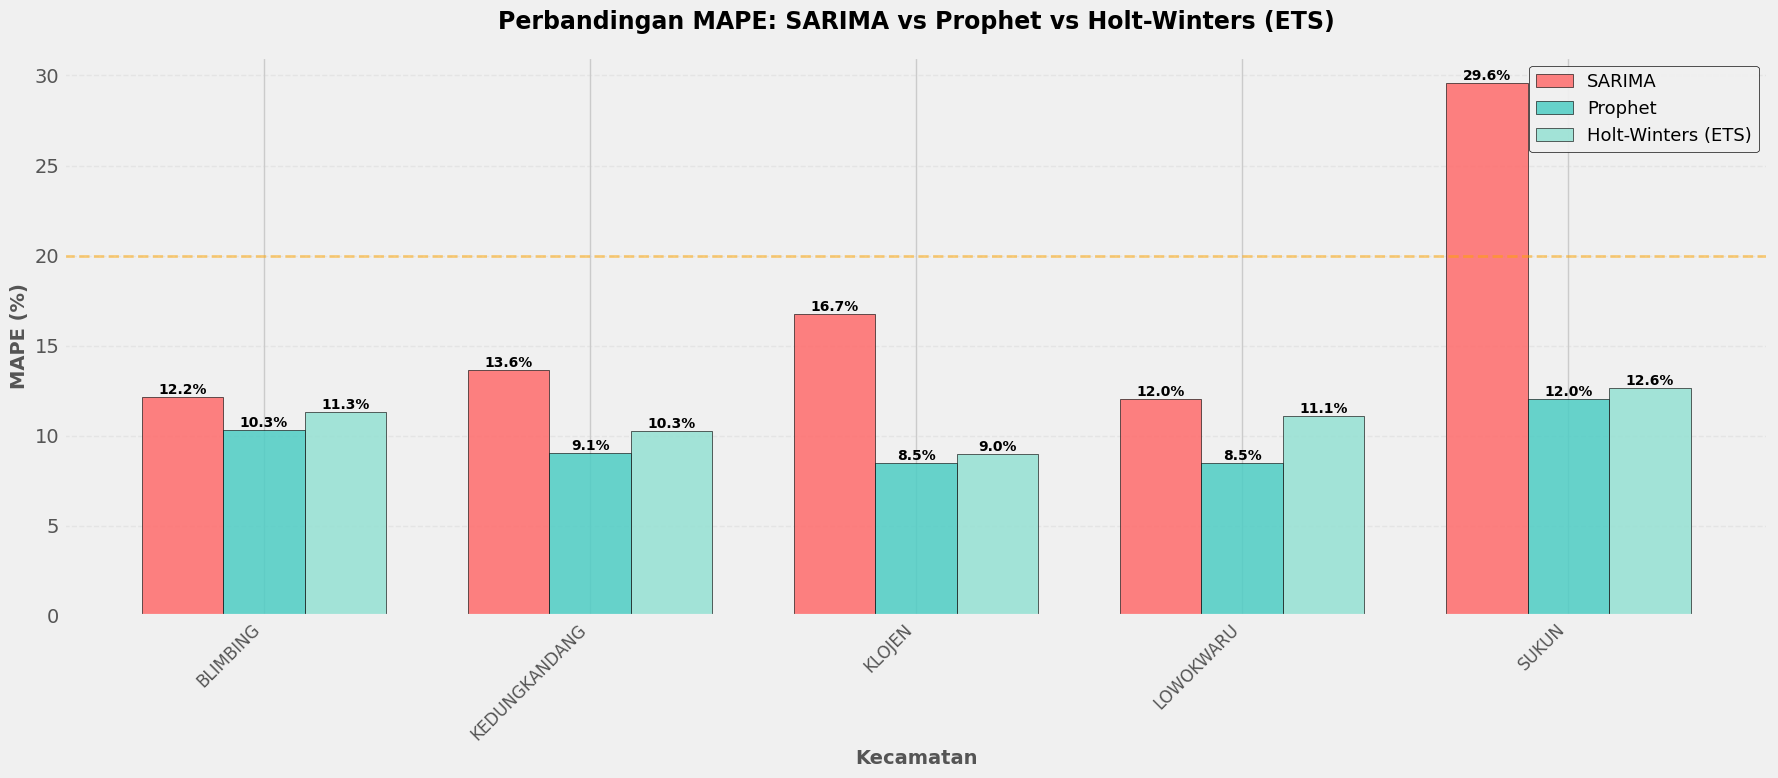


DETAIL PERBANDINGAN PER KECAMATAN

BLIMBING:
   - SARIMA:        12.15%
   - Prophet:       10.29%
   - Holt-Winters:  11.33%
   - Terbaik:       Prophet

KEDUNGKANDANG:
   - SARIMA:        13.63%
   - Prophet:       9.05%
   - Holt-Winters:  10.25%
   - Terbaik:       Prophet

KLOJEN:
   - SARIMA:        16.75%
   - Prophet:       8.51%
   - Holt-Winters:  9.00%
   - Terbaik:       Prophet

LOWOKWARU:
   - SARIMA:        12.05%
   - Prophet:       8.50%
   - Holt-Winters:  11.08%
   - Terbaik:       Prophet

SUKUN:
   - SARIMA:        29.56%
   - Prophet:       12.04%
   - Holt-Winters:  12.63%
   - Terbaik:       Prophet



In [9]:
# Visualisasi 1: Bar Chart Perbandingan MAPE
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(unique_kecamatan))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['SARIMA_MAPE'], width, 
                label='SARIMA', color='#FF6B6B', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x, comparison_df['Prophet_MAPE'], width, 
                label='Prophet', color='#4ECDC4', alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + width, comparison_df['HoltWinters_MAPE'], width, 
                label='Holt-Winters (ETS)', color='#95E1D3', alpha=0.85, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')

ax.set_xlabel('Kecamatan', fontsize=14, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=14, fontweight='bold')
ax.set_title('Perbandingan MAPE: SARIMA vs Prophet vs Holt-Winters (ETS)', 
              fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(unique_kecamatan, rotation=45, ha='right', fontsize=12)
ax.legend(loc='upper right', fontsize=13, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.axhline(y=20, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Threshold Baik (20%)')

plt.tight_layout()
plt.show()

# Visualisasi 2: Detail per Kecamatan
print(f"\n{'='*90}")
print("DETAIL PERBANDINGAN PER KECAMATAN")
print(f"{'='*90}\n")

for kec in unique_kecamatan:
    sarima = comparison_df.loc[kec, 'SARIMA_MAPE']
    prophet = comparison_df.loc[kec, 'Prophet_MAPE']
    hw = comparison_df.loc[kec, 'HoltWinters_MAPE']
    best = comparison_df.loc[kec, 'Model_Terbaik']
    
    print(f"{kec}:")
    print(f"   - SARIMA:        {sarima:.2f}%")
    print(f"   - Prophet:       {prophet:.2f}%")
    print(f"   - Holt-Winters:  {hw:.2f}%")
    print(f"   - Terbaik:       {best}")
    print()

## Kesimpulan dan Rekomendasi

In [10]:
print("="*90)
print("KESIMPULAN DAN REKOMENDASI")
print("="*90)

print("\nHASIL PERBANDINGAN MODEL:")
print("-"*90)

# Summary MAPE
print(f"\n   Rata-rata MAPE (Mean Absolute Percentage Error):")
print(f"      - SARIMA:        {comparison_df['SARIMA_MAPE'].mean():.4f}%")
print(f"      - Prophet:       {comparison_df['Prophet_MAPE'].mean():.4f}%")
print(f"      - Holt-Winters:  {comparison_df['HoltWinters_MAPE'].mean():.4f}%")

# Summary MAE
print(f"\n   Rata-rata MAE (Mean Absolute Error):")
print(f"      - SARIMA:        {comparison_df['SARIMA_MAE'].mean():.2f} paket")
print(f"      - Prophet:       {comparison_df['Prophet_MAE'].mean():.2f} paket")
print(f"      - Holt-Winters:  {comparison_df['HoltWinters_MAE'].mean():.2f} paket")

# Summary RMSE
print(f"\n   Rata-rata RMSE (Root Mean Squared Error):")
print(f"      - SARIMA:        {comparison_df['SARIMA_RMSE'].mean():.2f} paket")
print(f"      - Prophet:       {comparison_df['Prophet_RMSE'].mean():.2f} paket")
print(f"      - Holt-Winters:  {comparison_df['HoltWinters_RMSE'].mean():.2f} paket")

# Ranking
print(f"\n   Ranking Model (Berdasarkan Rata-rata MAPE):")
models_ranking = [
    ('SARIMA', comparison_df['SARIMA_MAPE'].mean()),
    ('Prophet', comparison_df['Prophet_MAPE'].mean()),
    ('Holt-Winters', comparison_df['HoltWinters_MAPE'].mean())
]
models_ranking.sort(key=lambda x: x[1])

for i, (model, mape) in enumerate(models_ranking, 1):
    medal = ['1', '2', '3'][i-1]
    print(f"      {medal} Rank {i}: {model} (MAPE: {mape:.4f}%)")

# Model terbaik per kecamatan
print(f"\n\nMODEL TERBAIK PER KECAMATAN:")
print("-"*90)

for kec in unique_kecamatan:
    best = comparison_df.loc[kec, 'Model_Terbaik']
    sarima_mape = comparison_df.loc[kec, 'SARIMA_MAPE']
    prophet_mape = comparison_df.loc[kec, 'Prophet_MAPE']
    hw_mape = comparison_df.loc[kec, 'HoltWinters_MAPE']
    
    print(f"\n   {kec}:")
    print(f"      Model Terpilih: {best}")
    print(f"      MAPE: SARIMA={sarima_mape:.2f}%, Prophet={prophet_mape:.2f}%, HW={hw_mape:.2f}%")

# Analisis karakteristik
print(f"\n\nANALISIS KARAKTERISTIK MODEL:")
print("-"*90)

print(f"\n   SARIMA:")
print(f"       Kelebihan:")
print(f"        - Bagus untuk data stasioner dan seasonal pattern yang jelas")
print(f"        - Parameter (p,d,q)(P,D,Q,s) dapat disesuaikan detail")
print(f"        - Cocok untuk data dengan trend linear")
print(f"       Kekurangan:")
print(f"        - Sensitif terhadap outlier")
print(f"        - Membutuhkan data yang cukup banyak (min 2 seasonal cycles)")
print(f"        - Proses tuning parameter memakan waktu")

print(f"\n    Prophet:")
print(f"       Kelebihan:")
print(f"        - Dapat handle missing data dan outliers dengan baik")
print(f"        - Bisa incorporate holiday effects (hari libur Indonesia)")
print(f"        - Interpretable components (trend, seasonality, holidays)")
print(f"       Kekurangan:")
print(f"        - Kadang overfitting pada data dengan variasi tinggi")
print(f"        - Membutuhkan tuning changepoint_prior_scale yang tepat")

print(f"\n    Holt-Winters (ETS):")
print(f"       Kelebihan:")
print(f"        - Sederhana dan cepat untuk ditraining")
print(f"        - Cocok untuk data dengan seasonal pattern yang stabil")
print(f"        - Support additive dan multiplicative seasonality")
print(f"       Kekurangan:")
print(f"        - Kurang fleksibel untuk multiple seasonality")
print(f"        - Tidak bisa handle holiday effects secara eksplisit")
print(f"        - Sensitif terhadap perubahan pattern yang tiba-tiba")

# Rekomendasi
print(f"\n\n REKOMENDASI UNTUK DOSEN:")
print("-"*90)

best_overall = models_ranking[0][0]
best_overall_mape = models_ranking[0][1]

print(f"\n   Berdasarkan hasil evaluasi:")
print(f"      - Model TERBAIK secara keseluruhan: {best_overall}")
print(f"      - Dengan rata-rata MAPE: {best_overall_mape:.4f}%")

if best_overall_mape < 10:
    status_text = "SANGAT BAIK (< 10%)"
elif best_overall_mape < 20:
    status_text = "BAIK (10-20%)"
elif best_overall_mape < 50:
    status_text = "CUKUP (20-50%)"
else:
    status_text = "PERLU IMPROVEMENT (> 50%)"

print(f"      - Status akurasi: {status_text}")

print(f"\n   Rekomendasi Implementasi:")
print(f"      1. Gunakan {best_overall} sebagai model utama untuk produksi")
print(f"      2. Lakukan re-training model setiap bulan dengan data terbaru")
print(f"      3. Monitor performa model secara berkala (MAPE, MAE, RMSE)")
print(f"      4. Gunakan ensemble method (kombinasi 2-3 model) untuk hasil lebih robust")
print(f"      5. Pertimbangkan external factors: promo, event, musim liburan")

print("\n" + "="*90)
print("ANALISIS SELESAI!")
print("="*90)

KESIMPULAN DAN REKOMENDASI

HASIL PERBANDINGAN MODEL:
------------------------------------------------------------------------------------------

   Rata-rata MAPE (Mean Absolute Percentage Error):
      - SARIMA:        16.8285%
      - Prophet:       9.6775%
      - Holt-Winters:  10.8588%

   Rata-rata MAE (Mean Absolute Error):
      - SARIMA:        186.18 paket
      - Prophet:       113.86 paket
      - Holt-Winters:  122.66 paket

   Rata-rata RMSE (Root Mean Squared Error):
      - SARIMA:        235.46 paket
      - Prophet:       218.91 paket
      - Holt-Winters:  199.55 paket

   Ranking Model (Berdasarkan Rata-rata MAPE):
      1 Rank 1: Prophet (MAPE: 9.6775%)
      2 Rank 2: Holt-Winters (MAPE: 10.8588%)
      3 Rank 3: SARIMA (MAPE: 16.8285%)


MODEL TERBAIK PER KECAMATAN:
------------------------------------------------------------------------------------------

   BLIMBING:
      Model Terpilih: Prophet
      MAPE: SARIMA=12.15%, Prophet=10.29%, HW=11.33%

   KEDUNGK

## Export Hasil untuk Laporan

In [11]:
# Export hasil perbandingan ke Excel untuk laporan skripsi
output_excel = '../data/model_comparison_results.xlsx'

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Sheet 1: Perbandingan MAPE
    comparison_df[['SARIMA_MAPE', 'Prophet_MAPE', 'HoltWinters_MAPE', 'Model_Terbaik']].to_excel(
        writer, sheet_name='MAPE Comparison'
    )
    
    # Sheet 2: Perbandingan MAE
    comparison_df[['SARIMA_MAE', 'Prophet_MAE', 'HoltWinters_MAE']].to_excel(
        writer, sheet_name='MAE Comparison'
    )
    
    # Sheet 3: Perbandingan RMSE
    comparison_df[['SARIMA_RMSE', 'Prophet_RMSE', 'HoltWinters_RMSE']].to_excel(
        writer, sheet_name='RMSE Comparison'
    )
    
    # Sheet 4: Summary Statistics
    summary_stats = pd.DataFrame({
        'Metric': ['Rata-rata MAPE (%)', 'Rata-rata MAE', 'Rata-rata RMSE', 
                   'Jumlah Kemenangan', 'Std Dev MAPE'],
        'SARIMA': [
            comparison_df['SARIMA_MAPE'].mean(),
            comparison_df['SARIMA_MAE'].mean(),
            comparison_df['SARIMA_RMSE'].mean(),
            (comparison_df['Model_Terbaik'] == 'SARIMA').sum(),
            comparison_df['SARIMA_MAPE'].std()
        ],
        'Prophet': [
            comparison_df['Prophet_MAPE'].mean(),
            comparison_df['Prophet_MAE'].mean(),
            comparison_df['Prophet_RMSE'].mean(),
            (comparison_df['Model_Terbaik'] == 'Prophet').sum(),
            comparison_df['Prophet_MAPE'].std()
        ],
        'Holt_Winters': [
            comparison_df['HoltWinters_MAPE'].mean(),
            comparison_df['HoltWinters_MAE'].mean(),
            comparison_df['HoltWinters_RMSE'].mean(),
            (comparison_df['Model_Terbaik'] == 'Holt-Winters').sum(),
            comparison_df['HoltWinters_MAPE'].std()
        ]
    })
    summary_stats.to_excel(writer, sheet_name='Summary Statistics', index=False)
    
    # Sheet 5: Parameter SARIMA (NEW!)
    sarima_params_df = pd.DataFrame({
        'Kecamatan': list(sarima_optimal_params.keys()),
        'Order_p': [params['order'][0] for params in sarima_optimal_params.values()],
        'Order_d': [params['order'][1] for params in sarima_optimal_params.values()],
        'Order_q': [params['order'][2] for params in sarima_optimal_params.values()],
        'Seasonal_P': [params['seasonal_order'][0] for params in sarima_optimal_params.values()],
        'Seasonal_D': [params['seasonal_order'][1] for params in sarima_optimal_params.values()],
        'Seasonal_Q': [params['seasonal_order'][2] for params in sarima_optimal_params.values()],
        'Seasonal_s': [params['seasonal_order'][3] for params in sarima_optimal_params.values()],
        'AIC': [sarima_results[kec]['model'].aic for kec in sarima_optimal_params.keys()],
        'BIC': [sarima_results[kec]['model'].bic for kec in sarima_optimal_params.keys()]
    })
    sarima_params_df.to_excel(writer, sheet_name='SARIMA Parameters', index=False)
    
    # Sheet 6: Parameter Holt-Winters
    hw_params_df = pd.DataFrame({
        'Kecamatan': list(holtwinters_results.keys()),
        'Trend': [res['params']['trend'] for res in holtwinters_results.values()],
        'Seasonal': [res['params']['seasonal'] for res in holtwinters_results.values()],
        'Damped_Trend': [res['params']['damped_trend'] for res in holtwinters_results.values()],
        'Seasonal_Periods': [52] * len(holtwinters_results)
    })
    hw_params_df.to_excel(writer, sheet_name='HW Parameters', index=False)
    
    # Sheet 7: Parameter Prophet
    prophet_params_df = pd.DataFrame({
        'Kecamatan': list(prophet_optimal_params.keys()),
        'Changepoint_Prior_Scale': [params['changepoint_prior_scale'] for params in prophet_optimal_params.values()],
        'Seasonality_Prior_Scale': [params['seasonality_prior_scale'] for params in prophet_optimal_params.values()],
        'Seasonality_Mode': [params['seasonality_mode'] for params in prophet_optimal_params.values()],
        'N_Changepoints': [params['n_changepoints'] for params in prophet_optimal_params.values()]
    })
    prophet_params_df.to_excel(writer, sheet_name='Prophet Parameters', index=False)

print("="*90)
print(f"Hasil perbandingan berhasil di-export!")
print(f"File disimpan di: {output_excel}")
print("="*90)

# Export parameter optimal ke JSON untuk semua model
all_params = {
    'sarima': sarima_optimal_params,
    'prophet': prophet_optimal_params,
    'holtwinters': {kec: res['params'] for kec, res in holtwinters_results.items()}
}

with open('../data/all_optimal_params.json', 'w') as f:
    json.dump(all_params, f, indent=4)

print(f"\nSemua parameter optimal disimpan di: ../data/all_optimal_params.json")

Hasil perbandingan berhasil di-export!
File disimpan di: ../data/model_comparison_results.xlsx

Semua parameter optimal disimpan di: ../data/all_optimal_params.json
